In [201]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

## Einlesen & Zusammenfassen der CSV Files

- Zusammenfassen mittels Glob
- Einlesen mittels read_csv
- Seperieren mit |

In [202]:
# 1. Find the files
all_files = glob.glob("data/*.csv")

# 2. This creates a LIST of DataFrames
df_list = [pd.read_csv(filename, sep="|") for filename in all_files]

# 3. This combines that list into a SINGLE DataFrame
df = pd.concat(df_list, axis=0, ignore_index=True)

# 4. View the result
print(df.head())

  Num_Kids  Loan_ID  Gender Married  Dependent_No     Education  \
0        -    27471    Male    True             1  Not Graduate   
1        -    27472    Male   False             1      Graduate   
2        -    27473  Female   False             4  Not Graduate   
3        -    27474    Male   False             3      Graduate   
4        -    27475    Male    True             3  Not Graduate   

   Self_Employed  Applicant_Income  CoApplicant_Income  Loan_Amount  \
0           True              4251             34868.0        30000   
1          False             23399             30710.0        30000   
2           True             68684             13669.0        50000   
3           True             19825             20862.0        10000   
4           True             65643             15199.0        60000   

   Loan_Amount_Term  Credit History Property_District  Loan_Status  
0               300               1               CCR            1  
1                60             

## Indentifikation von Datenproblemen & Behebung Duplikate

- Duplikate
- NaN Gender values


In [203]:
for col in df.columns:
    if df[col].isna().sum() > 0:
        print(f"sum of nan {col} = {df[col].isna().sum()}")

print(f"\nsum of duplicates = {df.duplicated().sum()}")

df["Gender"] = df["Gender"].fillna("Unknown")
print("\nNaN Gender values replaced with 'Unknown'")

df = df.drop_duplicates()
print(f"Duplicates removed. Remaining duplicates: {df.duplicated().sum()}")


sum of nan Gender = 3
sum of nan CoApplicant_Income = 508

sum of duplicates = 5

NaN Gender values replaced with 'Unknown'
Duplicates removed. Remaining duplicates: 0


## Visualisierung der Zielklasse

**Ziel**: Risiko von Zahlungsausfällen minimieren
-> **Zielklasse** = Loan_Status

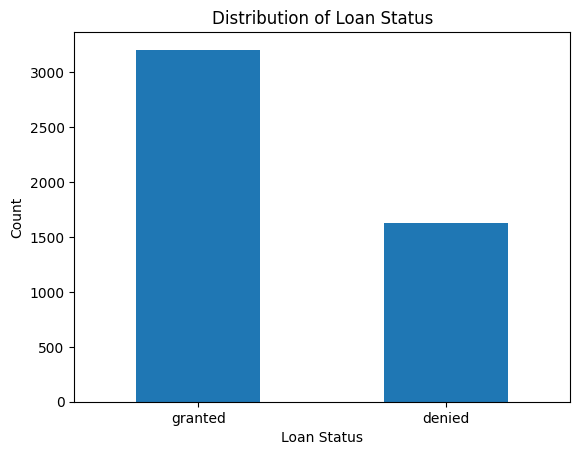

In [204]:

status_labels = {1: "granted", 0: "denied"}

loan_counts = df["Loan_Status"].map(status_labels).value_counts()
loan_counts = loan_counts.reindex(["granted", "denied"])
loan_counts.plot(kind="bar")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.title("Distribution of Loan Status")
target_counts = df["Loan_Status"].map(status_labels).value_counts()

plt.xticks(rotation=0)


plt.show()

## Kredite in urbanen Gegend

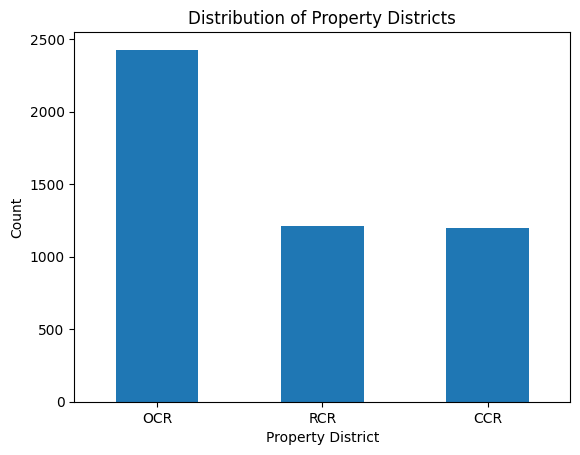

In [205]:
district_counts = df["Property_District"].value_counts()
district_counts.plot(kind="bar")
plt.xlabel("Property District")
plt.ylabel("Count")
plt.title("Distribution of Property Districts")
plt.xticks(rotation=0)
plt.show()

CCR -  Core Central Region (CCR) is Singapore

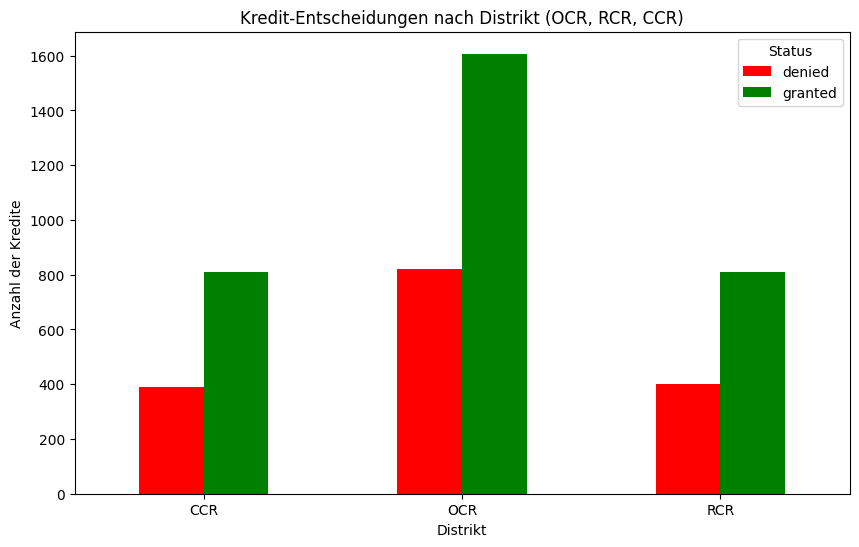

In [ ]:
district_comparison = df.groupby(['Property_District', 'Loan_Status']).size().unstack(fill_value=0)

district_comparison.columns = district_comparison.columns.map({1: 'granted', 0: 'denied'})

district_comparison = district_comparison[['denied', 'granted']]

district_comparison.plot(kind='bar', color=['red', 'green'], figsize=(10, 6))

plt.title('Kredit-Entscheidungen nach Distrikt (OCR, RCR, CCR)')
plt.xlabel('Distrikt')
plt.ylabel('Anzahl der Kredite')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.show()

## Durchschnittseinkommen

In [207]:
mean_income = round(df["Applicant_Income"].mean(), 2)
print(f"Mean Income: ${mean_income}")

Mean Income: $50986.77


## Bildungsstatus höchster Kredite

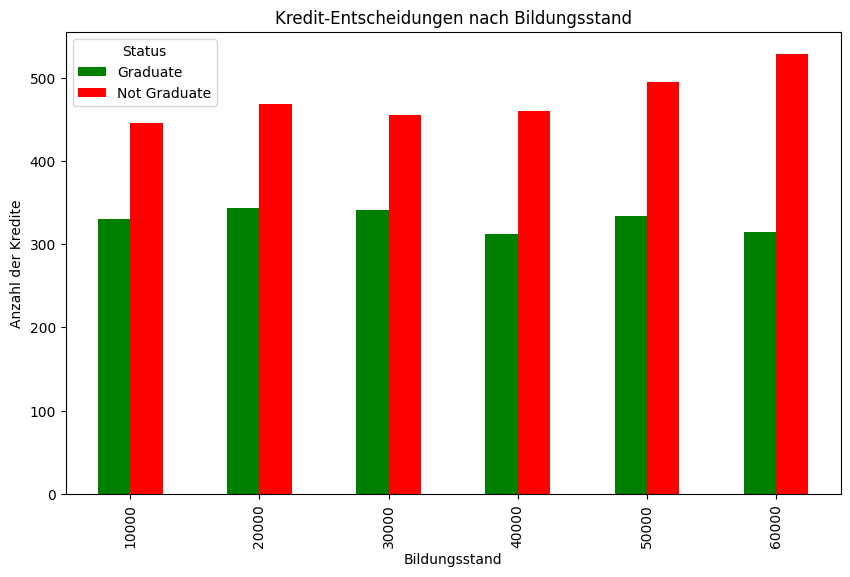

In [ ]:
loan_education_comparison = df.groupby("Loan_Amount")["Education"].value_counts().unstack(fill_value=0)

loan_education_comparison.plot(kind='bar', color=['green', 'red'], figsize=(10, 6))

plt.title('Kredit-Entscheidungen nach Bildungsstand')
plt.xlabel('Bildungsstand')
plt.ylabel('Anzahl der Kredite')
plt.legend(title='Status')
plt.show()

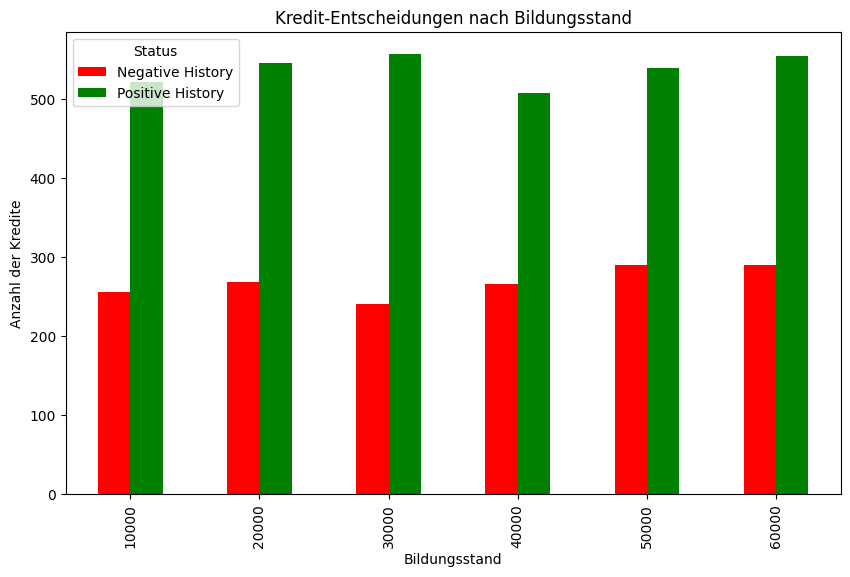

In [220]:
credit_history_education_comparison = df.groupby("Loan_Amount")["Credit History"].value_counts().unstack(fill_value=0)

credit_history_education_comparison.columns = credit_history_education_comparison.columns.map({0: 'Negative History', 1: 'Positive History'})

credit_history_education_comparison.plot(kind='bar', color=['red', 'green'], figsize=(10, 6))

plt.title('Kredit-Entscheidungen nach Bildungsstand')
plt.xlabel('Bildungsstand')
plt.ylabel('Anzahl der Kredite')
plt.legend(title='Status')
plt.show()